In [1]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import func_stats as fs
import func_plot as fp
import matplotlib.pyplot as plt
import seaborn as sns
from brainspace.gradient import GradientMaps
import networkx as nx
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from pygam import LinearGAM, s, f, l
from enigmatoolbox.permutation_testing import spin_test
import warnings
warnings.filterwarnings("ignore")

## Individual level

In [2]:
plt.rcParams["font.family"] = "Arial"

SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [3]:
spa=80 # top20%
df_impute = pd.read_csv('../data/df_impute.csv')
atlas = np.loadtxt('../src/fs_LR.dk.txt')
df_impute.loc[df_impute.DX==0, 'DX'] = -1

duration = np.array((df_impute['age'] - df_impute['AO']))
duration[duration<0] = np.nan
df_impute['duration'] = duration

df_scz = df_impute[df_impute.DX==1].reset_index(drop=True)
df_scz['subtype'] = np.loadtxt('../results/enigma_subtype.txt')
gm_ctr = np.loadtxt('../data/gm_ctr'+str(spa)+'.txt')

In [4]:
def cohen_d(m, t, x='DX', data=df_impute):
  dof = m[0].df_resid
  n1 = (data[x]==1).sum()
  n2 = (data[x]==-1).sum()
  d = (t * (n1 + n2)) / (pow(n1*n2, 0.5) * pow(dof, 0.5))
  return d

In [5]:
def save_df(model, filename, x='DX',data=df_impute):
    df_save = pd.DataFrame()
    df_save['Region'] = [label[:-9] for label in np.array(fp.region_list)]
    df_save[x+'_t'] = np.array([model[i].tvalues[x] for i in range(68)])
    df_save[x+'_p'] = np.array([model[i].pvalues[x] for i in range(68)])   
    df_save[x+'_pfdr'] = fs.fdr(np.array([model[i].pvalues[x] for i in range(68)]))
    try:
        df_save[x+'_cohen'] = [cohen_d(x=x,m=model, t=df_save[x+'_t'][i], data=data) for i in range(68)]
    except:
        pass
    df_save['age_t'] = np.array([model[i].tvalues['age'] for i in range(68)])
    df_save['age_p'] = np.array([model[i].pvalues['age'] for i in range(68)])   
    df_save['age_pfdr'] = fs.fdr(np.array([model[i].pvalues['age'] for i in range(68)]))
    df_save['sex_t'] = np.array([model[i].tvalues['sex'] for i in range(68)])
    df_save['sex_p'] = np.array([model[i].pvalues['sex'] for i in range(68)])   
    df_save['sex_pfdr'] = fs.fdr(np.array([model[i].pvalues['sex'] for i in range(68)]))
    try:
        df_save[x+'_age_t'] = np.array([model[i].tvalues[x+'_age'] for i in range(68)])
        df_save[x+'_age_p'] = np.array([model[i].pvalues[x+'_age'] for i in range(68)])   
        df_save[x+'_age_pfdr'] = fs.fdr(np.array([model[i].pvalues[x+'_age'] for i in range(68)]))
    except:
        pass
    try:
        df_save[x+'_sex_t'] = np.array([model[i].tvalues[x+'_sex'] for i in range(68)])
        df_save[x+'_sex_p'] = np.array([model[i].pvalues[x+'_sex'] for i in range(68)])   
        df_save[x+'_sex_pfdr'] = fs.fdr(np.array([model[i].pvalues[x+'_sex'] for i in range(68)]))
    except:
        pass
    df_save.to_csv(filename, index=None)

## Normative models

In [6]:
np.random.seed(0)
age_sex = np.array(df_impute[['age','sex','ICV']][df_impute.DX==-1])
brain = np.mean(df_impute[fp.region_list][df_impute.DX==-1], axis=1)
gam = LinearGAM(s(0)+f(1)+l(2))  # 's(0)' specifies a spline for the first (and only) feature
gam.gridsearch(age_sex, brain)

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + f(1) + l(2) + intercept, 
   tol=0.0001, verbose=False)

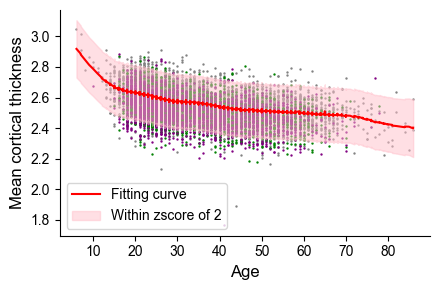

In [7]:
mean = gam.predict(age_sex)
ci = gam.prediction_intervals(age_sex, width=0.95)

fig, ax = plt.subplots(figsize=(4.5,3))
ax.scatter(age_sex[:,0], brain, c='grey', s=0.5)
ax.scatter(np.array(df_scz['age'][df_scz.subtype==-1]), 
           np.mean(df_scz[fp.region_list][df_scz.subtype==-1], axis=1), 
           c='green', s=0.5)
ax.scatter(np.array(df_scz['age'][df_scz.subtype==1]), 
           np.mean(df_scz[fp.region_list][df_scz.subtype==1], axis=1), 
           c='purple', s=0.5)

rank=age_sex[:,0].argsort()
ax.plot(age_sex[:,0][rank], mean[rank], 'r', label="Fitting curve")
ax.fill_between(
    age_sex[:,0][rank],
    ci[:,0][rank],
    ci[:,1][rank],
    color='pink', alpha=0.5,
    label="Within zscore of 2"
)

ax.set_xlabel("Age")
ax.set_ylabel("Mean cortical thickness")
ax.set_xticks([10,20,30,40,50,60,70,80])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.legend(loc='lower left')
fig.tight_layout()
fig.savefig('../figures/meanCT_CTR.png', transparent=True, dpi=300)

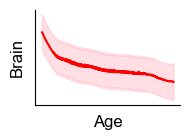

In [8]:
mean = gam.predict(age_sex)
ci = gam.prediction_intervals(age_sex, width=0.95)

fig, ax = plt.subplots(figsize=(2,1.5))
rank=age_sex[:,0].argsort()
ax.plot(age_sex[:,0][rank], mean[rank], 'r')
ax.fill_between(
    age_sex[:,0][rank],
    ci[:,0][rank],
    ci[:,1][rank],
    color='pink', alpha=0.5)

ax.set_xlabel("Age")
ax.set_ylabel("Brain")
ax.set_xticks([])
ax.set_yticks([])

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

fig.tight_layout()
fig.savefig('../figures/meanCT_CTR_example.png', transparent=True, dpi=300)

In [9]:
s1 = np.array(df_scz[['age','sex','ICV']][df_scz.subtype==-1])
brain_s1 = np.mean(df_scz[fp.region_list][df_scz.subtype==-1], axis=1)
s2 = np.array(df_scz[['age','sex','ICV']][df_scz.subtype==1])
brain_s2 = np.mean(df_scz[fp.region_list][df_scz.subtype==1], axis=1)

mean_s1 = gam.predict(s1)
ci_s1 = gam.prediction_intervals(s1, width=0.95)
mean_s2 = gam.predict(s2)
ci_s2 = gam.prediction_intervals(s2, width=0.95)

In [10]:
z_s1 = (brain_s1 - mean_s1)*4/(ci_s1[:,1]-ci_s1[:,0])
z_s2 = (brain_s2 - mean_s2)*4/(ci_s2[:,1]-ci_s2[:,0])
z_ctr = (brain - mean)*4/(ci[:,1]-ci[:,0])

[z_s1.mean(), z_s1.std(), (abs(z_s1) > 2).sum()/len(z_s1),
 z_s2.mean(), z_s2.std(), (abs(z_s2) > 2).sum()/len(z_s2),
 z_ctr.mean(),z_ctr.std(), (abs(z_ctr) > 2).sum()/len(z_ctr),
 ss.ttest_ind(z_s1, z_s2),  
 ss.ttest_ind(z_ctr, z_s1),
 ss.ttest_ind(z_ctr, z_s2)]

[-0.5380226046902468,
 1.0462517757421872,
 0.09317647058823529,
 -0.6622872383874057,
 1.1027005675794075,
 0.11729405346426623,
 -3.0226701314724137e-05,
 1.0177737567052187,
 0.04518127163417745,
 TtestResult(statistic=3.6338490557228065, pvalue=0.0002827710520422687, df=3956.0),
 TtestResult(statistic=20.52736697418942, pvalue=3.492487675238591e-91, df=7612.0),
 TtestResult(statistic=23.61239182334409, pvalue=7.308521764107265e-119, df=7320.0)]

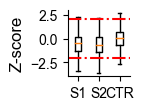

In [11]:
fig, ax = plt.subplots(figsize=(1.5,1.2))
rank=age_sex[:,0].argsort()
ax.boxplot([z_s1,z_s2,z_ctr], widths=0.3, sym='', vert=True)

ax.set_ylabel("Z-score")
ax.set_xticklabels(['S1','S2','CTR'])

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.hlines(y=[-2,2],xmin=0.5,xmax=3.5,colors='red',linestyles='-.')

fig.tight_layout()
fig.savefig('../figures/meanCT_zscores.png', transparent=True, dpi=300)

In [12]:
df_test=df_scz[['age','sex','ICV','subtype']]
df_test['mean_z'] = np.zeros(len(df_test))
df_test['mean_z'][df_scz.subtype==-1] = np.array(z_s1)
df_test['mean_z'][df_scz.subtype==1] = np.array(z_s2)
df_test['age'][np.logical_and(df_test['age']<15, df_test['age']>65)] = np.nan
df_test = df_test.dropna()
df_test['subtype_age'] = df_test['subtype'] * df_test['age']
df_test['subtype_sex'] = df_test['subtype'] * df_test['sex']
model_demo = OLS(df_test['mean_z'], add_constant(df_test[['age','sex','ICV','subtype','subtype_age']])).fit()
model_demo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 mean_z   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.898
Date:                Wed, 11 Feb 2026   Prob (F-statistic):             0.0129
Time:                        18:40:28   Log-Likelihood:                -5892.5
No. Observations:                3958   AIC:                         1.180e+04
Df Residuals:                    3952   BIC:                         1.183e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.4995      0.218     -2.286      0.022      -0.928      -0.071
age            -0.0011      0.001     -0.786      0.432      -0.004       0.002
sex             0.0093      0.042      0.219      0.826      -0.073       0.092
ICV         -4.946e-08   1.17e-07     -0.424      0.672   -2.78e-07    1.79e-07
subtype        -0.0911      0.052     -1.753      0.080      -0.193       0.011
subtype_age     0.0008      0.001      0.566      0.571      -0.002       0.004
==============================================================================
Omnibus:                       65.553   Durbin-Watson:                   1.790
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              112.342
Skew:                          -0.123   Prob(JB):                     4.03e-25
Kurtosis:                       3.788   Cond. No.                     1.95e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.95e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [13]:
model_demo = OLS(df_test['mean_z'], add_constant(df_test[['age','sex','ICV','subtype','subtype_sex']])).fit()
model_demo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 mean_z   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     2.984
Date:                Wed, 11 Feb 2026   Prob (F-statistic):             0.0108
Time:                        18:40:28   Log-Likelihood:                -5892.3
No. Observations:                3958   AIC:                         1.180e+04
Df Residuals:                    3952   BIC:                         1.183e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.4994      0.218     -2.287      0.022      -0.928      -0.071
age            -0.0011      0.001     -0.782      0.434      -0.004       0.002
sex             0.0104      0.042      0.245      0.806      -0.072       0.093
ICV         -5.096e-08   1.17e-07     -0.436      0.663    -2.8e-07    1.78e-07
subtype        -0.1055      0.052     -2.046      0.041      -0.207      -0.004
subtype_sex     0.0306      0.035      0.867      0.386      -0.039       0.100
==============================================================================
Omnibus:                       66.210   Durbin-Watson:                   1.790
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              113.846
Skew:                          -0.124   Prob(JB):                     1.90e-25
Kurtosis:                       3.793   Cond. No.                     1.95e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.95e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

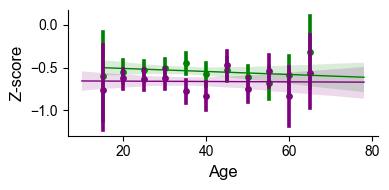

In [14]:
fig, ax = plt.subplots(figsize=(4,2))

sns.regplot(x=df_scz.loc[z_s1.index]['age'], 
            y=z_s1,
            ax=ax, x_bins=np.arange(15, 70, 5), color='green',
            scatter_kws={'s':15}, line_kws={'lw':1})

sns.regplot(x=df_scz.loc[z_s2.index]['age'], 
            y=z_s2,
            ax=ax, x_bins=np.arange(15, 70, 5), color='purple',
            scatter_kws={'s':15}, line_kws={'lw':1})

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlabel('Age')
ax.set_ylabel('Z-score')
fig.tight_layout()
fig.savefig('../figures/meanCT_zscores_s1s2.png', transparent=True, dpi=300)

In [15]:
df_test=df_scz[['age','sex','ICV','duration','subtype']]
df_test['mean_z'] = np.zeros(len(df_test))
df_test['mean_z'][df_scz.subtype==-1] = np.array(z_s1)
df_test['mean_z'][df_scz.subtype==1] = np.array(z_s2)
df_test['age'][np.logical_and(df_test['age']<15, df_test['age']>65)] = np.nan
df_test = df_test.dropna()
df_test['subtype_duration'] = df_test['subtype'] * df_test['duration']
model_demo = OLS(df_test['mean_z'], add_constant(df_test[['age','sex','ICV','duration','subtype','subtype_duration']])).fit()
model_demo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 mean_z   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.093
Date:                Wed, 11 Feb 2026   Prob (F-statistic):             0.0509
Time:                        18:40:28   Log-Likelihood:                -4788.3
No. Observations:                3201   AIC:                             9591.
Df Residuals:                    3194   BIC:                             9633.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.3850      0.249     -1.545      0.122      -0.874       0.104
age                 -0.0001      0.002     -0.065      0.949      -0.005       0.004
sex                 -0.0418      0.048     -0.864      0.388      -0.137       0.053
ICV              -1.078e-07   1.32e-07     -0.815      0.415   -3.67e-07    1.52e-07
duration             0.0004      0.002      0.155      0.877      -0.004       0.005
subtype             -0.0849      0.026     -3.274      0.001      -0.136      -0.034
subtype_duration     0.0023      0.002      1.344      0.179      -0.001       0.006
==============================================================================
Omnibus:                       62.263   Durbin-Watson:                   1.809
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              107.168
Skew:                          -0.153   Prob(JB):                     5.36e-24
Kurtosis:                       3.842   Cond. No.                     1.99e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.99e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

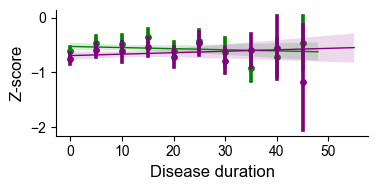

In [16]:
fig, ax = plt.subplots(figsize=(4,2))

sns.regplot(x=df_test[df_test.subtype==-1]['duration'], 
            y=df_test[df_test.subtype==-1]['mean_z'],
            ax=ax, x_bins=np.arange(0, 50, 5), color='green',
            scatter_kws={'s':15}, line_kws={'lw':1})

sns.regplot(x=df_test[df_test.subtype==1]['duration'], 
            y=df_test[df_test.subtype==1]['mean_z'],
            ax=ax, x_bins=np.arange(0, 50, 5), color='purple',
            scatter_kws={'s':15}, line_kws={'lw':1})

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xlabel('Disease duration')
ax.set_ylabel('Z-score')
fig.tight_layout()
fig.savefig('../figures/meanCT_zscores_s1s2_duration.png', transparent=True, dpi=300)

In [17]:
gam_region = [None] * 68
for i in range(68):
  brain = np.array(df_impute[fp.region_list[i]][df_impute.DX==-1])
  age_sex = np.array(df_impute[['age','sex','ICV']][df_impute.DX==-1])
  gam_region[i] = LinearGAM(s(0)+s(1)+l(2))  # 's(0)' specifies a spline for the first (and only) feature
  gam_region[i].gridsearch(age_sex, brain)

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############           

In [18]:
def s_region(model, x_s1, x_s2, y_s1, y_s2):
  mean_s1 = model.predict(x_s1)
  ci_s1 = model.prediction_intervals(x_s1, width=0.95)
  mean_s2 = model.predict(x_s2)
  ci_s2 = model.prediction_intervals(x_s2, width=0.95)
  z_s1 = (y_s1 - mean_s1)*4/(ci_s1[:,1]-ci_s1[:,0])
  z_s2 = (y_s2 - mean_s2)*4/(ci_s2[:,1]-ci_s2[:,0])
  return [z_s1, z_s2]

def cohen_d_g(n1,n2,t):
  dof = n1+n2-2
  d = (t * (n1 + n2)) / (pow(n1*n2, 0.5) * pow(dof, 0.5))
  return d

In [44]:
x_s1 = np.array(df_scz[['age','sex','ICV']][df_scz.subtype==-1])
x_s2 = np.array(df_scz[['age','sex','ICV']][df_scz.subtype==1])
x_ctr = np.array(df_impute[['age','sex','ICV']][df_impute.DX==-1])

z_s1 = [None] * 68
z_s2 = [None] * 68
z_ctr = [None] * 68
for i in range(68):
  y_s1 = np.array(df_scz[fp.region_list[i]][df_scz.subtype==-1])
  y_s2 = np.array(df_scz[fp.region_list[i]][df_scz.subtype==1])
  z_s1[i],z_s2[i] = s_region(gam_region[i], x_s1=x_s1,x_s2=x_s2,y_s1=y_s1,y_s2=y_s2)
  y_ctr = np.array(df_impute[fp.region_list[i]][df_impute.DX==-1])
  tmp_mean = gam_region[i].predict(x_ctr)
  tmp_ci = gam_region[i].prediction_intervals(x_ctr, width=0.95)
  z_ctr[i] = (y_ctr - tmp_mean)*2/(tmp_ci[:,1]-tmp_ci[:,0])

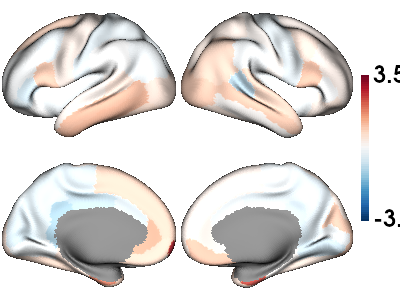

In [45]:
t = np.zeros(68)
p = np.zeros(68)
for i in range(68):
    df_test=df_scz[['age','sex','ICV','subtype']]
    df_test['mean_z'] = np.zeros(len(df_test))
    df_test['mean_z'][df_scz.subtype==-1] = z_s1[i]
    df_test['mean_z'][df_scz.subtype==1] = z_s2[i]
    df_test['age'][np.logical_and(df_test['age']<15, df_test['age']>65)] = np.nan
    df_test = df_test.dropna()
    df_test['subtype_age'] = df_test['subtype'] * df_test['age']
    df_test['subtype_sex'] = df_test['subtype'] * df_test['sex']
    model_demo = OLS(df_test['mean_z'], add_constant(df_test[['age','sex','ICV','subtype','subtype_age']])).fit()
    t[i] = model_demo.tvalues['subtype_age']
    p[i] = model_demo.pvalues['subtype_age']

df_tosave = pd.DataFrame()
df_tosave['Region'] = fp.region_list
df_tosave['subtype_age_t'] = t
df_tosave['subtype_age_p'] = p
df_tosave['subtype_age_pfdr'] = fs.fdr(p)
df_tosave.to_csv('../results/enigma_subtype_age_interaction.csv', index=False)

tmp=[t.copy()]
#tmp[0][p>0.01] = 0
plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(400,300*len(tmp)), cmap='RdBu_r', color_range=(-3.5,3.5),layout_style = 'grid',
                display=True, filename='../figures/GAM_subtype_age_s1s2.png')

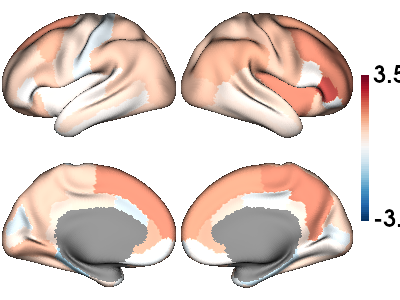

In [46]:
t = np.zeros(68)
p = np.zeros(68)
for i in range(68):
    df_test=df_scz[['age','sex','ICV','subtype']]
    df_test['mean_z'] = np.zeros(len(df_test))
    df_test['mean_z'][df_scz.subtype==-1] = z_s1[i]
    df_test['mean_z'][df_scz.subtype==1] = z_s2[i]
    df_test['age'][np.logical_and(df_test['age']<15, df_test['age']>65)] = np.nan
    df_test = df_test.dropna()
    df_test['subtype_sex'] = df_test['subtype'] * df_test['sex']
    model_demo = OLS(df_test['mean_z'], add_constant(df_test[['age','sex','ICV','subtype','subtype_sex']])).fit()
    t[i] = model_demo.tvalues['subtype_sex']
    p[i] = model_demo.pvalues['subtype_sex']

df_tosave = pd.DataFrame()
df_tosave['Region'] = fp.region_list
df_tosave['subtype_sex_t'] = t
df_tosave['subtype_sex_p'] = p
df_tosave['subtype_sex_pfdr'] = fs.fdr(p)
df_tosave.to_csv('../results/enigma_subtype_sex_interaction.csv', index=False)

tmp=[t.copy()]
#tmp[0][p>0.01] = 0
plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(400,300*len(tmp)), cmap='RdBu_r', color_range=(-3.5,3.5),layout_style = 'grid',
                display=True, filename='../figures/GAM_subtype_sex_s1s2.png')

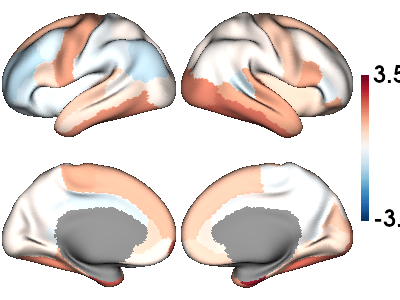

In [47]:
t = np.zeros(68)
p = np.zeros(68)
for i in range(68):
    df_test=df_scz[['age','sex','ICV','duration','subtype']]
    df_test['mean_z'] = np.zeros(len(df_test))
    df_test['mean_z'][df_scz.subtype==-1] = z_s1[i]
    df_test['mean_z'][df_scz.subtype==1] = z_s2[i]
    df_test['age'][np.logical_and(df_test['age']<15, df_test['age']>65)] = np.nan
    df_test = df_test.dropna()
    df_test['subtype_duration'] = df_test['subtype'] * df_test['duration']
    model_demo = OLS(df_test['mean_z'], add_constant(df_test[['age','sex','ICV','duration','subtype','subtype_duration']])).fit()
    t[i] = model_demo.tvalues['subtype_duration']
    p[i] = model_demo.pvalues['subtype_duration']

df_tosave = pd.DataFrame()
df_tosave['Region'] = fp.region_list
df_tosave['subtype_duration_t'] = t
df_tosave['subtype_duration_p'] = p
df_tosave['subtype_duration_pfdr'] = fs.fdr(p)
df_tosave.to_csv('../results/enigma_subtype_duration_interaction.csv', index=False)

tmp=[t.copy()]
#tmp[0][p>0.01] = 0
plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(400,300*len(tmp)), cmap='RdBu_r', color_range=(-3.5,3.5),layout_style = 'grid',
                display=True, filename='../figures/GAM_subtype_duration_s1s2.png')

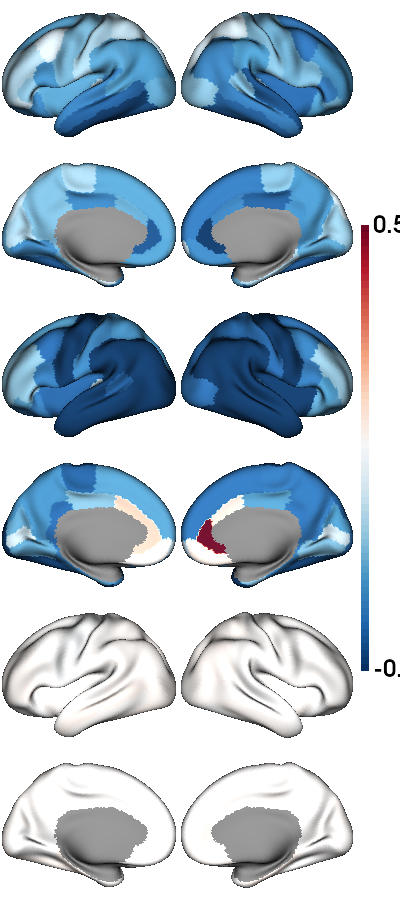

In [79]:
age1=55
age2=65

s1_mean = np.array([z_s1[i][np.logical_and(x_s1[:,0]>=age1, x_s1[:,0]<age2)].mean() for i in range(68)])
s2_mean = np.array([z_s2[i][np.logical_and(x_s2[:,0]>=age1, x_s2[:,0]<age2)].mean() for i in range(68)])
ctr_mean = np.array([z_ctr[i][np.logical_and(x_ctr[:,0]>=age1, x_ctr[:,0]<age2)].mean() for i in range(68)])
s1_ratio = np.array([(abs(z_s1[i][np.logical_and(x_s1[:,0]>=age1, x_s1[:,0]<age2)]) > 2).sum()/np.logical_and(x_s1[:,0]>=age1, x_s1[:,0]<age2).sum() for i in range(68)])
s2_ratio = np.array([(abs(z_s2[i][np.logical_and(x_s2[:,0]>=age1, x_s2[:,0]<age2)]) > 2).sum()/np.logical_and(x_s2[:,0]>=age1, x_s2[:,0]<age2).sum() for i in range(68)])
ctr_ratio = np.array([(abs(z_ctr[i][np.logical_and(x_ctr[:,0]>=age1, x_ctr[:,0]<age2)]) > 2).sum()/np.logical_and(x_ctr[:,0]>=age1, x_ctr[:,0]<age2).sum() for i in range(68)])

tp = np.array([ss.ttest_ind(z_s1[i][np.logical_and(x_s1[:,0]>=age1, x_s1[:,0]<age2)], 
              z_s2[i][np.logical_and(x_s2[:,0]>=age1, x_s2[:,0]<age2)]) for i in range(68)])

cohen = np.array([cohen_d_g(n1=np.logical_and(x_s1[:,0]>=age1, x_s1[:,0]<age2).sum(),
                            n2=np.logical_and(x_s2[:,0]>=age1, x_s2[:,0]<age2).sum(),
                            t=-tp[i,0]) for i in range(68)]) # t is negative because s1 is coded as -1
df_tosave = pd.DataFrame()
df_tosave['Region'] = fp.region_list
df_tosave['N_Subtype1'] = np.logical_and(x_s1[:,0]>=age1, x_s1[:,0]<age2).sum()
df_tosave['N_Subtype2'] = np.logical_and(x_s2[:,0]>=age1, x_s2[:,0]<age2).sum()
df_tosave['N_CTR'] = np.logical_and(x_ctr[:,0]>=age1, x_ctr[:,0]<age2).sum()
df_tosave['CTR_mean_deviation'] = ctr_mean
df_tosave['Subtype1_mean_deviation'] = s1_mean
df_tosave['Subtype2_mean_deviation'] = s2_mean
df_tosave['Subtype_cohen_d'] = cohen
df_tosave['Subtype_t'] = tp[:,0]
df_tosave['Subtype_p'] = tp[:,1]
df_tosave['Subtype_pFDR'] = fs.fdr(tp[:,1])
df_tosave['CTR_ratio'] = ctr_ratio
df_tosave['Subtype1_ratio'] = s1_ratio
df_tosave['Subtype2_ratio'] = s2_ratio
df_tosave.to_csv('../results/enigma_ct/GAM_subtype_mean_age'+str(age1)+'to'+str(age2)+'.csv', index=None)


tmp=[s1_mean,s2_mean,ctr_mean]

plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(400,300*len(tmp)), cmap='RdBu_r', color_range=(-0.5,0.5),layout_style = 'grid',
                display=True, filename='../figures/GAM_subtype_mean_age'+str(age1)+'to'+str(age2)+'.png')

In [80]:
[s1_ratio.mean(), s1_ratio.std(), 
 s2_ratio.mean(), s2_ratio.std(),
 ctr_ratio.mean(),ctr_ratio.std(), 
 ss.ttest_rel(s1_ratio, s2_ratio), 
 ss.ttest_rel(ctr_ratio, s1_ratio),
 ss.ttest_rel(ctr_ratio, s2_ratio)]

[0.05388655462184873,
 0.019385588866898118,
 0.06516227180527386,
 0.024039132096645568,
 0.0007666573738500139,
 0.0013746224507468652,
 TtestResult(statistic=-3.1829731669148127, pvalue=0.00221118956480715, df=67),
 TtestResult(statistic=-22.388312100053135, pvalue=8.137062934903855e-33, df=67),
 TtestResult(statistic=-21.75288669992891, pvalue=4.450404658131026e-32, df=67)]

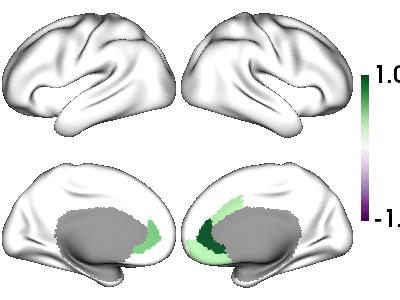

In [81]:
tmp=[cohen.copy()]
tmp[0][fs.fdr(tp[:,1])>0.05] = 0
plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(400,300*len(tmp)), cmap='PRGn', color_range=(-1,1),layout_style = 'grid',
                display=True, filename='../figures/GAM_subtype_t_'+str(age1)+str(age2)+'.png')

permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000
permutation 100 of 1000
permutation 200 of 1000
permutation 300 of 1000
permutation 400 of 1000
permutation 500 of 1000
permutation 600 of 1000
permutation 700 of 1000
permutation 800 of 1000
permutation 900 of 1000
permutation 1000 of 1000


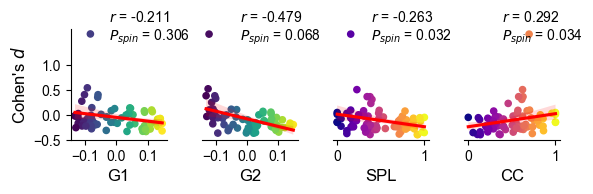

In [82]:
ctr_cc = np.loadtxt('../data/cluster_ctr80.txt')
ctr_spl = np.loadtxt('../data/length_ctr80.txt')
x = [gm_ctr[:,0], gm_ctr[:,1], ctr_spl, ctr_cc]

fig, ax = plt.subplots(1,4, figsize=(6,2))

for i in range(2):
    ax[i].scatter(x[i], cohen, 
               c=x[i], cmap='viridis', s=20)
    sns.regplot(x=x[i], y=cohen, ax=ax[i],
                color='red', scatter_kws={'s':0})
    ax[i+2].scatter(x[i+2], cohen, 
               c=x[i+2], cmap='plasma', s=20)
    sns.regplot(x=x[i+2], y=cohen, ax=ax[i+2],
                color='red', scatter_kws={'s':0})

for i in range(4):
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['left'].set_visible(False)
    ax[i].set_yticks([])
    rp = [None] * 2
    rp[0] = ss.spearmanr(x[i], cohen)[0]
    tmp = spin_test(x[i], cohen, surface_name='fsa5', parcellation_name='aparc',
          type='spearman', n_rot=1000, null_dist=False)
    rp[1] = tmp
    if rp[1]<0.001:
        rp[1] = '< 0.001'
    else:
        rp[1] = '= '+str(np.round(rp[1],3))
    ax[i].text(0.4, 0.9, '$\it{r}$ = '+str(np.round(rp[0],3))+'\n'+'$\it{P}$$_{spin}$ '+str(rp[1]), transform=ax[i].transAxes)
    ax[i].set_xlabel(['G1','G2','SPL','CC'][i])

ax[0].spines['left'].set_visible(True)
ax[0].set_yticks([-0.5,0,0.5,1])
ax[0].set_ylabel('Cohen\'s $\it{d}$')

fig.tight_layout()
fig.savefig('../figures/'+str(spa)+'_subtype_space_age'+str(age1)+'to'+str(age2)+'.png', transparent=True, dpi=300)

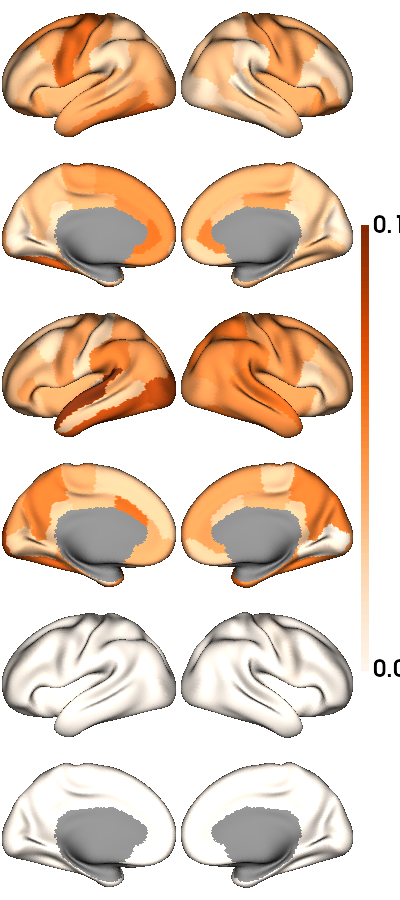

In [83]:
tmp=[s1_ratio,s2_ratio, ctr_ratio]

plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(400,300*len(tmp)), cmap='Oranges', color_range=(0,0.15),layout_style = 'grid',
                display=True, filename='../figures/GAM_subtype_ratio_'+str(age1)+str(age2)+'.png')

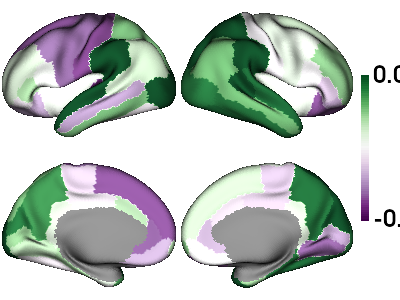

In [84]:
tmp=[s2_ratio-s1_ratio]

plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(400,300*len(tmp)), cmap='PRGn', color_range=(-0.05,0.05),layout_style = 'grid',
                display=True, filename='../figures/GAM_subtype_ratiodiff_'+str(age1)+str(age2)+'.png')

In [29]:
x_tmp = duration[df_impute.DX==1]
x_tmp = x_tmp[np.isnan(x_tmp)==False]
x_tmp.mean(), x_tmp.std(), x_tmp.min(), x_tmp.max()

(10.11827580427679, 11.19918091523439, 0.0, 55.0)

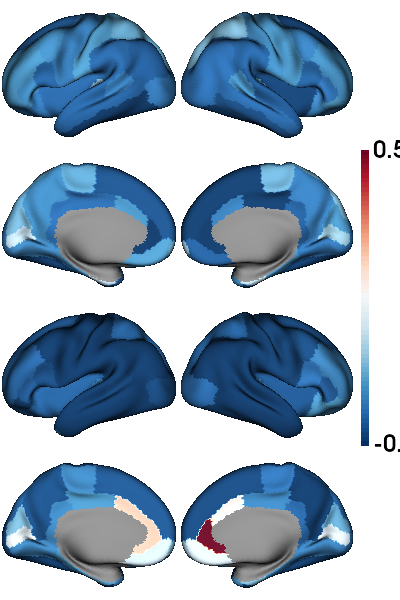

In [42]:
age1=20
age2=55

x_s1 = df_scz.duration[df_scz.subtype==-1]
x_s2 = df_scz.duration[df_scz.subtype==1]

s1_mean = np.array([z_s1[i][np.logical_and(x_s1>=age1, x_s1<age2)].mean() for i in range(68)])
s2_mean = np.array([z_s2[i][np.logical_and(x_s2>=age1, x_s2<age2)].mean() for i in range(68)])

s1_ratio = np.array([(abs(z_s1[i][np.logical_and(x_s1>=age1, x_s1<age2)]) > 2).sum()/np.logical_and(x_s1>=age1, x_s1<age2).sum() for i in range(68)])
s2_ratio = np.array([(abs(z_s2[i][np.logical_and(x_s2>=age1, x_s2<age2)]) > 2).sum()/np.logical_and(x_s2>=age1, x_s2<age2).sum() for i in range(68)])

tp = np.array([ss.ttest_ind(z_s1[i][np.logical_and(x_s1>=age1, x_s1<age2)], 
              z_s2[i][np.logical_and(x_s2>=age1, x_s2<age2)]) for i in range(68)])

cohen = np.array([cohen_d_g(n1=np.logical_and(x_s1>=age1, x_s1<age2).sum(),
                            n2=np.logical_and(x_s2>=age1, x_s2<age2).sum(),
                            t=-tp[i,0]) for i in range(68)]) # t is negative because s1 is coded as -1
df_tosave = pd.DataFrame()
df_tosave['Region'] = fp.region_list
df_tosave['N_Subtype1'] = np.logical_and(x_s1>=age1, x_s1<age2).sum()
df_tosave['N_Subtype2'] = np.logical_and(x_s2>=age1, x_s2<age2).sum()
df_tosave['Subtype1_mean_deviation'] = s1_mean
df_tosave['Subtype2_mean_deviation'] = s2_mean
df_tosave['Subtype_cohen_d'] = cohen
df_tosave['Subtype_t'] = tp[:,0]
df_tosave['Subtype_p'] = tp[:,1]
df_tosave['Subtype_pFDR'] = fs.fdr(tp[:,1])
df_tosave['Subtype1_ratio'] = s1_ratio
df_tosave['Subtype2_ratio'] = s2_ratio
df_tosave.to_csv('../results/enigma_ct/GAM_subtype_mean_duration'+str(age1)+'to'+str(age2)+'.csv', index=None)

tmp=[s1_mean,s2_mean]

plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(400,300*len(tmp)), cmap='RdBu_r', color_range=(-0.5,0.5),layout_style = 'grid',
                display=True, filename='../figures/GAM_subtype_mean_duration'+str(age1)+'to'+str(age2)+'.png')

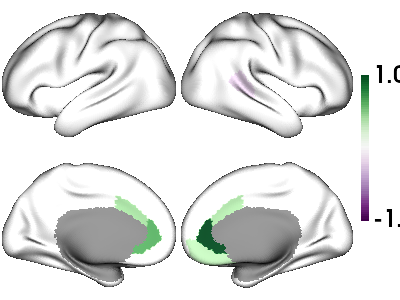

In [43]:
tmp=[cohen.copy()]
tmp[0][fs.fdr(tp[:,1])>0.05] = 0
plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(400,300*len(tmp)), cmap='PRGn', color_range=(-1,1),layout_style = 'grid',
                display=True, filename='../figures/GAM_subtype_t_duration'+str(age1)+str(age2)+'.png')